# Project 2 - Fun with Filters and Frequencies

In [130]:
# load libraries
import numpy as np
from scipy.signal import convolve2d
import skimage as sk
import skimage.io as skio
from skimage import img_as_ubyte
import time
import matplotlib.pyplot as plt
import cv2

## Part 1: Fun with Filters

### 1.1 Convolutions from Scratch

In [131]:
# 4 for loops
def conv4(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    padh, padw = kh // 2, kw // 2 # pad height and width

    # flip kernel horizontally + vertically
    kernel = np.flipud(np.fliplr(kernel)) # flipud = vertical flip (up, down), fliplr = horizontal (left, right)

    # pad with zeros on all sides
    padded = np.pad(img, ((padh, padh), (padw, padw)), mode = 'constant')
    out = np.zeros_like(img) # output array stores convolved values

    for i in range(h): # loop over image
        for j in range(w):
            val = 0
            for m in range(kh): # loop over kernel
                for n in range(kw):
                    val += padded[i + m, j + n] * kernel[m, n]
            out[i, j] = val

    return out

In [132]:
# 2 for loops
def conv2(img, kernel):
    h, w = img.shape
    kh, kw = kernel.shape
    padh, padw = kh // 2, kw // 2 # pad height and width

    # flip kernel horizontally + vertically
    kernel = np.flipud(np.fliplr(kernel))

    # pad with zeros on all sides
    padded = np.pad(img, ((padh, padh), (padw, padw)), mode = 'constant')
    out = np.zeros_like(img) # output array stores convolved values

    for i in range(h): # loop over image
        for j in range(w):
            region = padded[i:i + kh, j:j + kw] # region of interest
            out[i, j] = np.sum(region * kernel) # multiplication and sum

    return out

In [133]:
# comparison

# test
img = skio.imread('pics/wtc.jpg', as_gray = True) # read as grayscale
img = sk.img_as_float(img) # convert to float

kernel = np.ones((3,3)) / 9 # box filter

# manual = conv2(img, kernel)
# scipy_out = convolve2d(img, kernel, mode = 'same', boundary = 'fill', fillvalue = 0)

# skio.imsave('output/manual.png', img_as_ubyte(manual))
# skio.imsave('output/scipy.png', img_as_ubyte(scipy_out))

# print("Difference:", np.max(np.abs(manual - scipy_out)))
# difference seems very small

# time manual convolution
start_time = time.time()
manual = conv2(img, kernel)
manual_time = time.time() - start_time

# time manual convolution with conv4
start_time = time.time()
manual4 = conv4(img, kernel)
manual4_time = time.time() - start_time

# time scipy convolution
start_time = time.time()
scipy_out = convolve2d(img, kernel)
scipy_time = time.time() - start_time

# save
skio.imsave('output/manual.png', img_as_ubyte(manual))
skio.imsave('output/manual4.png', img_as_ubyte(manual4))
skio.imsave('output/scipy.png', img_as_ubyte(scipy_out))

# comparison results
# print("Pixel difference:", np.max(np.abs(manual - scipy_out)))

# compare shapes
print("Manual shape (2 for loops):", manual.shape)
print("Manual shape (4 for loops):", manual4.shape)
print("Scipy shape:", scipy_out.shape)
print(f"Manual conv2() time: {manual_time:.4f} seconds")
print(f"Manual conv4() time: {manual4_time:.4f} seconds")
print(f"Scipy convolve2d() time: {scipy_time:.4f} seconds")
print(f"Speedup ratio: {manual_time/scipy_time:.2f}x")

if manual_time > scipy_time:
    print(f"Scipy is {manual_time/scipy_time:.2f}x faster than manual implementation")
else:
    print(f"Manual implementation is {scipy_time/manual_time:.2f}x faster than scipy")

Manual shape (2 for loops): (1210, 907)
Manual shape (4 for loops): (1210, 907)
Scipy shape: (1212, 909)
Manual conv2() time: 4.0847 seconds
Manual conv4() time: 3.7522 seconds
Scipy convolve2d() time: 0.0387 seconds
Speedup ratio: 105.68x
Scipy is 105.68x faster than manual implementation


In [134]:
# picture
img = skio.imread('pics/wtc.jpg', as_gray = True) # read as grayscale
img = sk.img_as_float(img) # convert to float

box_kernel = np.ones((9, 9)) / 81 # 9 x 9 box filter, divide by 81 to average out and avoid brightness

convolved = conv2(img, box_kernel) # convolve image with box filter
skio.imsave('output/wtc.png', img_as_ubyte(convolved)) # save result

In [135]:
# 9x9 box filter with scipy
convolved = convolve2d(img, box_kernel)
skio.imsave('output/wtc_scipy.png', img_as_ubyte(convolved)) # save result

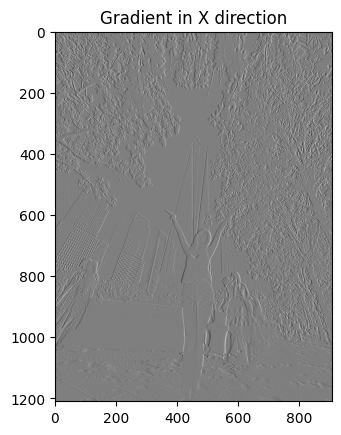

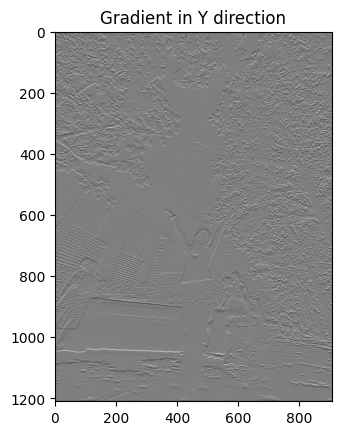

In [136]:
# with finite difference operators
dx = np.array([[1, 0, -1]])
dy = np.array([[1], [0], [-1]])

grad_x = conv2(img, dx)
grad_y = conv2(img, dy)

# saving as image vs plt figure?? looks different
skio.imsave('output/grad_x.png', img_as_ubyte(np.clip(np.abs(grad_x), 0, 1)))
skio.imsave('output/grad_y.png', img_as_ubyte(np.clip(np.abs(grad_y), 0, 1)))

plt.imshow(grad_x, cmap = 'gray')
plt.title('Gradient in X direction')
plt.savefig('output/plt_x.png')
plt.show()

plt.imshow(grad_y, cmap = 'gray')
plt.title('Gradient in Y direction')
plt.savefig('output/plt_y.png')
plt.show()

# seeing some vertical white lines (left side) of grad_x.png
# horizontal white lines (top) of grad_y.png

### 1.2 Finite Difference Operator

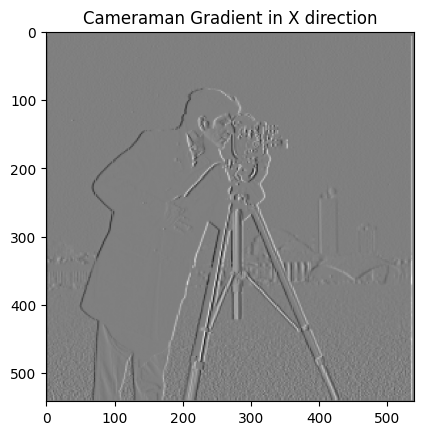

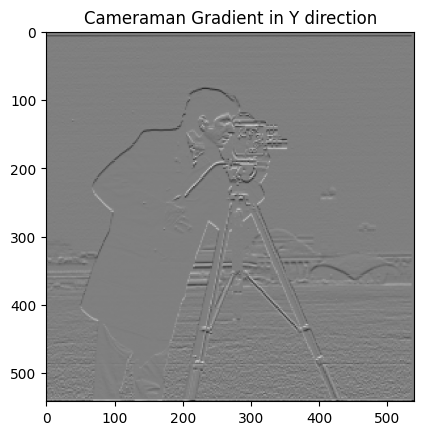

In [137]:
# finite different operator convolution of cameraman image
img = skio.imread('pics/cameraman.png', as_gray = True) # still waiting for image??
img = sk.img_as_float(img) # convert to float
cameraman_x = conv2(img, dx)
camerman_y = conv2(img, dy)

# show results with plt
plt.imshow(cameraman_x, cmap = 'gray')
plt.title('Cameraman Gradient in X direction')
plt.savefig('output/cameraman_x.png')
plt.show()

plt.imshow(camerman_y, cmap = 'gray')
plt.title('Cameraman Gradient in Y direction')
plt.savefig('output/cameraman_y.png')
plt.show()

# skio.imsave('output/cameraman_x.png', img_as_ubyte(np.clip(np.abs(cameraman_x), 0, 1)))
# skio.imsave('output/cameraman_y.png', img_as_ubyte(np.clip(np.abs(camerman_y), 0, 1)))

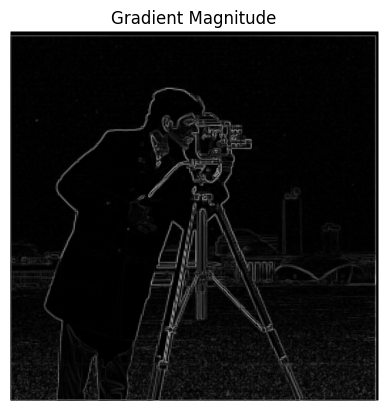

In [138]:
# compute and show gradient magnitude
grad_mag = np.sqrt(cameraman_x**2 + camerman_y**2)

plt.imshow(grad_mag, cmap="gray")
plt.title("Gradient Magnitude")
plt.axis("off")
plt.savefig('output/grad_mag.png')
plt.show()

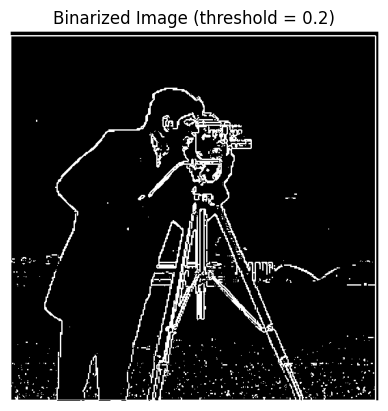

In [139]:
# turn into an edge image
# binarize gradient magnitude 

# pixels > threshold = edges (white), else background (black)
threshold = 0.20

# threshold too low -> noise, more white
# threshold too high -> only keep strong edges, lose details
edges = grad_mag > threshold

plt.imshow(edges, cmap = "gray")
plt.title(f"Binarized Image (threshold = {threshold})")
plt.axis("off")
plt.savefig('output/binarized_20.png')
plt.show()

### 1.3 Derivative of Gaussian (DoG) Filter

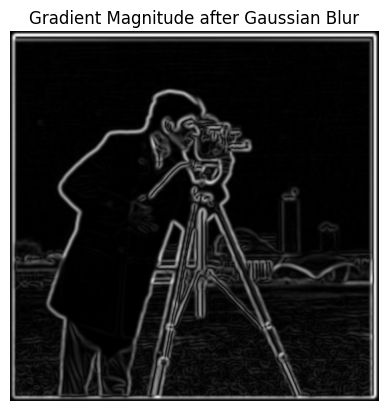

In [143]:
# convolve with gaussian filter G

# create Gaussian filter
# formula according to ed for kernel size k = 6sigma + 1
# if sigma = 2, k = 6(2) + 1 = 13
ksize = 13 # kernel size
sigma = 2 # sigma = standard deviation
g1d = cv2.getGaussianKernel(ksize, sigma)
G = g1d @ g1d.T # dot product to get 2D Gaussian filter

# blur image
blurred = convolve2d(img, G)

grad_x_blur = convolve2d(blurred, dx, mode = "same")
grad_y_blur = convolve2d(blurred, dy, mode = "same")
grad_mag_blur = np.sqrt(grad_x_blur**2 + grad_y_blur**2)

plt.imshow(grad_mag_blur, cmap="gray")
plt.title("Gradient Magnitude after Gaussian Blur")
plt.axis("off")
plt.savefig('output/grad_mag_blur.png')
plt.show()

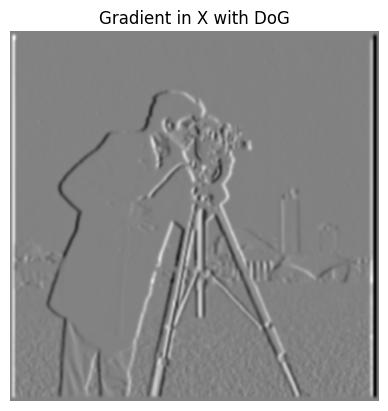

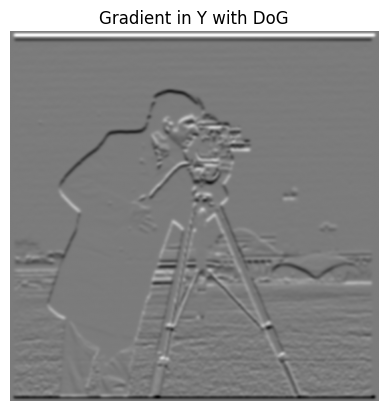

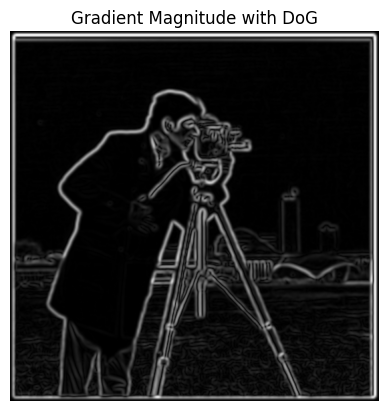

In [144]:
DoGx = convolve2d(G, dx, mode = "same")
DoGy = convolve2d(G, dy, mode = "same")

grad_x_dog = convolve2d(img, DoGx)
grad_y_dog = convolve2d(img, DoGy)
grad_mag_dog = np.sqrt(grad_x_dog**2 + grad_y_dog**2)

plt.imshow(grad_x_dog, cmap = "gray")
plt.title("Gradient in X with DoG")
plt.axis("off")
plt.savefig('output/grad_x_dog.png')
plt.show()

plt.imshow(grad_y_dog, cmap = "gray")
plt.title("Gradient in Y with DoG")
plt.axis("off")
plt.savefig('output/grad_y_dog.png')
plt.show()

plt.imshow(grad_mag_dog, cmap = "gray")
plt.title("Gradient Magnitude with DoG")
plt.axis("off")
plt.savefig('output/grad_mag_dog.png')
plt.show()

In [ ]:
print("max difference grad_x:", np.max(np.abs(grad_x_blur - grad_x_dog)))
print("max difference grad_y:", np.max(np.abs(grad_y_blur - grad_y_dog)))

max difference grad_x: 0.027630550638898868
max difference grad_y: 0.027630550638898965
